# Figure 5g: Annual cycle of sea ice area

Plots the annual cycle of the sea ice area in the Southern Ocean. The
cell area is computed manually for lat-lon models, as some models use a
different grid for `areacello` and `sic`.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

This is the quantitative counterpart of Figure 5: instead of two
contours it shows the total area covered by sea ice in each month,
obtained by weighting the concentration by the area of each grid cell.

The curve summarises both the amplitude of the seasonal cycle and the
timing of the maximum and minimum. Russell et al. (2018) highlight the
large spread across CMIP5 models, some producing far too little ice and
others far too much.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
import iris
import iris.coord_categorisation


# Constants used by the original NCL scripts
EARTH_RADIUS = 6.37e06   # m
DEG2RAD = 0.0174533


_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_DASHES = ["-", "--", "-.", ":"]
_MARKERS = ["o", "s", "D", "^", "v", "P", "X", "*"]


def style_for(index):
    """Line and marker style for the index-th dataset."""
    return {
        "color": _COLORS[index % len(_COLORS)],
        "dash": _DASHES[index % len(_DASHES)],
        "thick": 1.5,
        "mark": _MARKERS[index % len(_MARKERS)],
    }


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def has_regular_grid(cube):
    """True if the cube has 1D latitude and longitude coordinates."""
    return (cube.coord("latitude").ndim == 1
            and cube.coord("longitude").ndim == 1)


def lon_1d(cube):
    """A representative 1D longitude array (row 0 for 2D grids)."""
    lon = coord_1d_or_2d(cube, "longitude")
    return lon[0, :] if lon.ndim == 2 else lon


def monthly_climatology(cube):
    """12-month climatology of a monthly series (NCL clmMonTLL)."""
    if not any(c.name() == "month_number" for c in cube.coords()):
        iris.coord_categorisation.add_month_number(cube, "time")
    clim = cube.aggregated_by("month_number", iris.analysis.MEAN)
    return clim[np.argsort(clim.coord("month_number").points)]


def ncl_cell_area(lat, lon, shape):
    """Cell areas of a regular lat-lon grid, as computed in NCL.

    Replicates the manual areacello calculation of the NCL scripts:
    a constant dlat/dlon taken from grid points 19 and 20, then
    area = dx * dy with dx = R cos(lat) dlon and dy = R dlat.
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    dlat = abs(lat[20] - lat[19])
    dlon = abs(lon[20] - lon[19])
    dx = dlon * EARTH_RADIUS * DEG2RAD * np.cos(lat * DEG2RAD)
    dy = dlat * EARTH_RADIUS * DEG2RAD
    return np.broadcast_to((dx * dy)[:, np.newaxis], shape)

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41591 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/41591/status,
Dashboard: /proxy/41591/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32889,Workers: 0
Dashboard: /proxy/41591/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34543,Total threads: 2
Dashboard: /proxy/42425/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:39793,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

sic_datasets = {
    "ACCESS1-3": Dataset(
        short_name="sic",
        project="CMIP5",
        mip="OImon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="ACCESS1-3",
        timerange="19860101/20051231",
    ),
    "CanESM2": Dataset(
        short_name="sic",
        project="CMIP5",
        mip="OImon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
    "CCSM4": Dataset(
        short_name="sic",
        project="CMIP5",
        mip="OImon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CCSM4",
        timerange="19860101/20051231",
    ),
}

areacello_datasets = {
    "ACCESS1-3": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="ACCESS1-3",
        timerange="19860101/20051231",
    ),
    "CanESM2": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
    "CCSM4": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="CCSM4",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

This diagnostic works on the raw data (no preprocessor is applied), so
the cubes are only loaded here.  The time average is taken as part of
the diagnostic.

In [5]:
def preprocess(cube):
    """No preprocessing is applied for this figure."""
    return cube


sic_cubes = {name: preprocess(dataset.load()) for name, dataset in sic_datasets.items()}
areacello_cubes = {name: dataset.load() for name, dataset in areacello_datasets.items()}

sic_cubes

{'ACCESS1-3': <iris 'Cube' of sea_ice_area_fraction / (%) (time: 240; cell index along second dimension: 300; cell index along first dimension: 360)>,
 'CanESM2': <iris 'Cube' of sea_ice_area_fraction / (%) (time: 240; latitude: 64; longitude: 128)>,
 'CCSM4': <iris 'Cube' of sea_ice_area_fraction / (%) (time: 240; cell index along second dimension: 384; cell index along first dimension: 320)>}

## Diagnostic

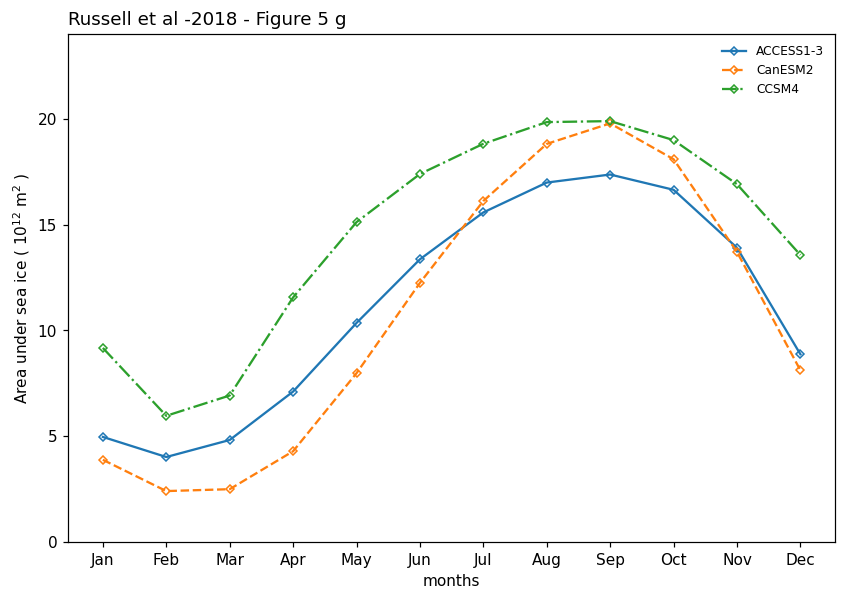

2026-09-22 08:24:55,827 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/base_events.py", line 691, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/locks.py", l

In [6]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, cube) in enumerate(sic_cubes.items()):
    clim = monthly_climatology(cube)
    sic = np.ma.masked_invalid(clim.data)
    if sic.max() < 5.0:
        sic = sic * 100.0

    lat = coord_1d_or_2d(clim, "latitude")
    if has_regular_grid(clim):
        # many lat-lon models carry sic on the atmosphere grid, so the
        # cell area is computed rather than read from areacello
        area = ncl_cell_area(lat, lon_1d(clim), sic.shape[1:])
        south = lat < 0.0
    else:
        area = np.ma.masked_invalid(areacello_cubes[name].data)
        south = lat[:, 0] < 0.0

    ice_area = sic * area[np.newaxis, :, :]
    # 1e14 = 1e12 (unit scale) * 100 (percent -> fraction)
    cycle = ice_area[:, south, :].reshape(12, -1).sum(axis=1) / 1.0e14

    style = style_for(i)
    ax.plot(np.arange(12), cycle, label=name, color=style["color"],
            linestyle=style["dash"], linewidth=style["thick"],
            marker="D", markersize=4, markerfacecolor="none")

ax.set_ylim(0, 24)
ax.set_xticks(np.arange(12))
ax.set_xticklabels(MONTHS)
ax.set_xlabel("months")
ax.set_ylabel(r"Area under sea ice ( 10$^{12}$ m$^2$ )")
ax.set_title("Russell et al -2018 - Figure 5 g", loc="left")
ax.legend(fontsize=8, frameon=False)
plt.show()

**Figure 5g: Annual cycle of sea ice area:** Annual cycle of the total Southern Hemisphere sea ice area (10^12 m^2).